In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def set_border(g):
    for spine in ['top', 'bottom', 'left', 'right']:
        g.spines[spine].set_color('black')
        g.spines[spine].set_linewidth(1)

def plot_var_bars_with_errorbars(
    summary,
    epochs,
    k_list=(1, 10, 100),
    title=None,
    path=None,
    logy=True,
):
    # 1. Update Layout: Smaller font, focused visuals
    sns.set_theme(style="whitegrid", font_scale=1.6, rc={"xtick.bottom": True, "ytick.left": True})
    sns.set_context(rc={'patch.linewidth': 1.5})

    labels = (
        [r"$\mathrm{Var}(u^\top z)$"]
        + [rf"$\sum_{{\ell=1}}^{{{k}}}\lambda_\ell^\perp$" for k in k_list]
        + [r"$\mathrm{tr}(\Sigma_\perp)$"]
    )
    metrics = ["var_u"] + [f"var_orth_top{k}" for k in k_list] + ["var_orth_total"]

    # Mocking data structure for demonstration if 'summary' isn't provided locally
    # (Ensure your 'summary' dict matches this structure)
    means = np.array([[summary[ep][m][0] for m in metrics] for ep in epochs], dtype=float)
    stds  = np.array([[summary[ep][m][1] for m in metrics] for ep in epochs], dtype=float)

    x = np.arange(len(epochs))
    K = len(metrics)

    # 2. Figure Size: Reduced from (16, 14) to (10, 8)
    fig, ax = plt.subplots(figsize=(10, 8))

    # 3. Bar Spacing (The "Pop"): 
    # Create a gap between the first bar (Blue) and the rest (Reds)
    width = 0.12
    gap_size = 0.08  # The physical gap size
    
    # Calculate standard offsets centered around 0
    base_offsets = (np.arange(K) - (K - 1) / 2) * width
    
    # Modify offsets to push Blue left and Reds right
    final_offsets = base_offsets.copy()
    final_offsets[0] -= gap_size      # Move Blue bar left
    final_offsets[1:] += gap_size     # Move Red bars right

    # Colors
    decision_color = "#1f77b4" # Standard Blue
    orth_color     = "#E65100" # Standard Orange
    
    # Make the red alphas slightly more opaque so they stand out as a "block"
    orth_alphas = np.linspace(0.4, 0.9, num=len(k_list) + 1)
    colors = [decision_color] + [orth_color] * (len(k_list) + 1)
    alphas = [1.0] + list(orth_alphas) # Keep Blue bar fully opaque (1.0)

    edgecolor = "black"
    err_kw = dict(ecolor="black", elinewidth=1.2, capsize=3, capthick=1.2)

    for t in range(K):
        ax.bar(
            x + final_offsets[t],
            means[:, t],
            width=width,
            yerr=stds[:, t],
            label=labels[t],
            color=colors[t],
            alpha=alphas[t],
            edgecolor=edgecolor,
            linewidth=1.2,
            error_kw=err_kw,
            zorder=3,
        )

    set_border(ax)
    ax.set_xticks(x)
    ax.set_xticklabels([str(e) for e in epochs])
    ax.set_xlabel("Epoch", fontweight='bold')
    ax.set_ylabel("Within-class variance", fontweight='bold')
    
    if title:
        ax.set_title(title, pad=40) # Add padding for the legend

    if logy:
        ax.set_yscale("log")

    ax.grid(False)

    # 4. Legend: Moved OUTSIDE and ABOVE
    ax.legend(
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02), # Coordinates relative to plot (0.5=center x, 1.02=just above top)
        ncol=5,                     # 3 columns fits well
        frameon=False,              # Clean look without box
        fontsize=16,
        handlelength=1.0,
        columnspacing=1.5
    )

    # 5. Annotation (Optional but recommended):
    # Highlights the gap at the last epoch
    last_idx = len(epochs) - 1
    blue_val = means[last_idx, 0]
    red_val_lowest = means[last_idx, 1] # The lowest of the red bars
    

    fig.tight_layout()

    if path:
        fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()

In [2]:
fpath = "../variance_viz/summary_pair_top10.csv"
import pandas as pd
df_summary = pd.read_csv(fpath)
summary = {}
for _, row in df_summary.iterrows():
    epoch = int(row['epoch'])
    summary[epoch] = {
        'var_u': (row['var_u_mean'], row['var_u_std']),
        'var_orth_top1': (row['var_orth_top1_mean'], row['var_orth_top1_std']),
        'var_orth_top10': (row['var_orth_top10_mean'], row['var_orth_top10_std']),
        'var_orth_top100': (row['var_orth_top100_mean'], row['var_orth_top100_std']),
        'var_orth_total': (row['var_orth_total_mean'], row['var_orth_total_std']),
    }
epochs = sorted(summary.keys())

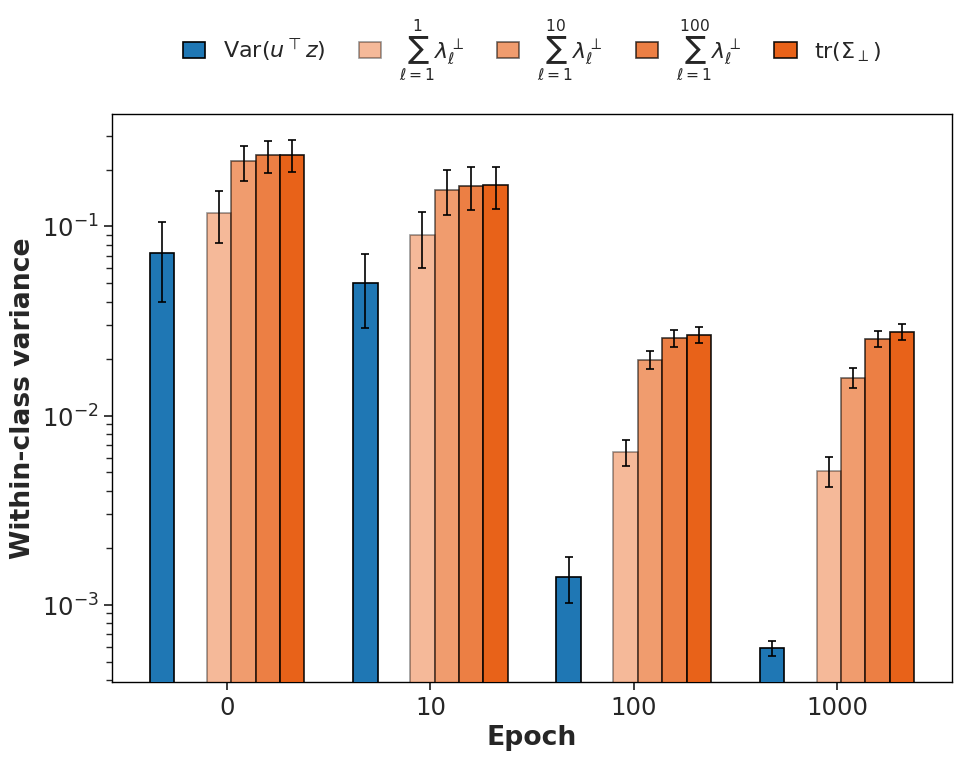

In [75]:
plot_var_bars_with_errorbars(
    summary,
    epochs,
    k_list=(1, 10, 100),
    path="../variance_viz/var_decomp_pair_top10.png",
    logy=True,
)